In [2]:
from foamdapy.tools import *
from foamdapy import EnSim2
from foamdapy.foamer import OFCase
import matplotlib.pyplot as plt
from foamdapy.ensemble_builder import ensemble_case_builder
import numpy as np
import shutil

# damBreakで1を作る

## 1.アンサンブルメンバの準備

In [3]:
%%bash
endir="./ensim1"
pwd_dir=`pwd`

rm -r $endir

# ディレクトリあるなら実行しない
if [ -d $endir ]; then exit; fi;
# OpenFOAMの環境変数を読み込んでいないなら実行しない
if [ ! -d $FOAM_TUTORIALS ]; then  exit; fi;

# ディレクトリ生成
mkdir -p $endir

# caseのコピー
cp -r ../of_cases/damBreak $endir/damBreak.org

# Allrun
cd $endir/damBreak.org ; ./Allrun

Restore 0/ from 0.orig/


Running interFoam on /home/katayamata/works/foamdapy/notebooks/ensim1/damBreak.org


In [4]:
endir="./ensim1"

casesbuilder = ensemble_case_builder(f"{endir}/damBreak.org",f"{endir}/member", "damBreakde1_")
casesbuilder.org_clones(20)

!ls ensim1/member


damBreakde1_00	damBreakde1_04	damBreakde1_08	damBreakde1_12	damBreakde1_16
damBreakde1_01	damBreakde1_05	damBreakde1_09	damBreakde1_13	damBreakde1_17
damBreakde1_02	damBreakde1_06	damBreakde1_10	damBreakde1_14	damBreakde1_18
damBreakde1_03	damBreakde1_07	damBreakde1_11	damBreakde1_15	damBreakde1_19


# データ同化

In [5]:
endir="./ensim1"

import random
from foamdapy import EnSim2
from foamdapy.variable import esarray
import numpy as np

random.seed(0)

n_cells = 2268
x_names = ["alpha.water", "alpha_wall"]
dim_x = 2268+50
y_names = ["alpha_wall"]
n_y_scaler = 1 #ベクトル問題解決までは = n_xscaler
n_ensemble = 20
n_obs_cells = 50
obs_cells = np.arange(n_cells,n_cells+n_obs_cells,1)

ensim = EnSim2(f"{endir}/member/", "damBreakde1_", x_names, 
               dim_x, n_ensemble, y_names,obs_cells,
               f"{endir}/damBreak.orig",4)

## y0定義(目的関数の定義)

In [6]:
from foamdapy.foamer import OFCase
import numpy as np

orgcase = OFCase("./ensim1/damBreak.org")
xf0 = orgcase.getValues("0",["alpha.water"])

cent = orgcase.getValues("0",["Cx"])
right_wall_index = np.where(cent == cent.max())[0]

val_1_indexes = [
    1507,1526,1545,1564,1583,1602,1621,1640,1659,1678,1697,1716,
    1735,1754,1773,1792,1811,1830,1849,1868,1887,1906,1925,1944,
    1963,1982,2001,2020,2039,2058,2077,2096,2115,2134,2153,2172]
all_cells = np.zeros(n_cells)
all_cells[val_1_indexes] = 1
ensim.y0 = all_cells[right_wall_index]


In [7]:
def Hx(xf, column_slice):
    if xf.ndim == 1: 
        return xf[column_slice]
    return xf[:, column_slice]

def get_y0(y0):
    return y0

ensim.func_Hx = Hx
ensim.y_indexes = obs_cells
ensim.R_diag = np.ones(ensim.y0.size)*0.001

## 変数の初期化

In [8]:
from foamdapy.variable import esarray, ColumnInfo
import numpy as np

np.random.seed(0)
ensim.xf = esarray(np.empty((n_ensemble,dim_x)))
ensim.xf.add_column_info("init_alpha","alpha.water","0",(0, n_cells))
ensim.xf.add_column_info("alpha_wall","alpha.water","0.45",(n_cells, dim_x),right_wall_index)
ensim.xf.all_load("init_alpha",ensim.case_dirs(),1)
ensim.xf.all_load("alpha_wall",ensim.case_dirs(),1)

ensim.xf += 0.5*(np.random.random(n_ensemble*dim_x).reshape(ensim.xf.shape)-0.5)
ensim.xf = np.clip(ensim.xf, 0,1)

colmninfo = ensim.xf.column_info

# DA loop

In [8]:
np.random.seed(0)

ensim.clear_log_dir()
ensim.craete_log_dir()

ensim.num_cpus = 10

ensim.start_ray()

for i in range(51):
    
    # xfをOpenFOAMに反映、予報計算
    ensim.xf.all_save("init_alpha",ensim.case_dirs(),1)
    del_names = ["PyFoam*","0.05","0.1","0.15","0.2","0.25","0.3","0.35","0.4","0.45"]
    for dname in del_names:
        ensim.clearPatternInCases(f"{dname}")

    ensim.ensemble_forcast("0.45")

    #xfのアップデート
    ensim.xf.all_load("init_alpha",ensim.case_dirs(),1)
    ensim.xf.all_load("alpha_wall",ensim.case_dirs(),1)

    # 残差をファイルに追記
    rmse = np.sqrt(np.mean(np.square(ensim.y0- ensim.xf[:,-50:].mean(axis=0))))
    rmsefile=f'{ensim.logdir}/rmse.txt'
    mode = 'a' if os.path.exists(f'{rmsefile}') else 'w'
    with open(f'{rmsefile}', "ab") as f:
        np.savetxt(f, [rmse], fmt='%.7f')
    print(f"Iteration {i}: Residual {rmse:.7f} saved.")

    ensim.letkf_update()
    ensim.xa = esarray(ensim.xa, ensim.xf.column_info)

    #inflation
    #RTPS
    xa_mean = ensim.xa.mean(axis=0)
    dxa = ensim.xa - xa_mean
    sigma_xa = ensim.xa.std(axis=0)
    sigma_xf = ensim.xf.std(axis=0)
    beta = 0.8
    with np.errstate(all='ignore'):
        rmd =(beta*sigma_xf +(1-beta)*sigma_xa)/sigma_xa
    rmd = np.nan_to_num(rmd)

    ensim.xa = xa_mean + rmd * dxa
    ensim.save_logs(f"{i}".zfill(2))

    ensim.xf = np.clip(ensim.xa,0,1)

ensim.shutdown_ray()
    

2024-07-27 02:36:38,714	INFO worker.py:1788 -- Started a local Ray instance.


Iteration 0: Residual 0.7620864 saved.
Iteration 1: Residual 0.6121280 saved.
Iteration 2: Residual 0.5507371 saved.
Iteration 3: Residual 0.6103942 saved.
Iteration 4: Residual 0.5678613 saved.
Iteration 5: Residual 0.5658806 saved.
Iteration 6: Residual 0.6038686 saved.
Iteration 7: Residual 0.5330348 saved.
Iteration 8: Residual 0.4801064 saved.
Iteration 9: Residual 0.4241199 saved.
Iteration 10: Residual 0.4253309 saved.
Iteration 11: Residual 0.4107313 saved.
Iteration 12: Residual 0.4370049 saved.
Iteration 13: Residual 0.4132591 saved.
Iteration 14: Residual 0.4331924 saved.
Iteration 15: Residual 0.4448535 saved.
Iteration 16: Residual 0.4061990 saved.
Iteration 17: Residual 0.4026246 saved.
Iteration 18: Residual 0.4081332 saved.
Iteration 19: Residual 0.3884395 saved.
Iteration 20: Residual 0.4058323 saved.
Iteration 21: Residual 0.3897048 saved.
Iteration 22: Residual 0.3925626 saved.
Iteration 23: Residual 0.3970830 saved.
Iteration 24: Residual 0.3901144 saved.
Iteration 

In [11]:
xf49 = np.load("./ensim1/member/logs/xf_iter_49.npy")

In [12]:
rmse = np.sqrt(np.mean(np.square(xf49[:,-50:] - ensim.y0),axis=1))
rmse.argmin(),rmse.min(),ensim.case_dirs()[rmse.argmin()]

(15, 0.36898707968153655, './ensim1/member/damBreakde1_04')

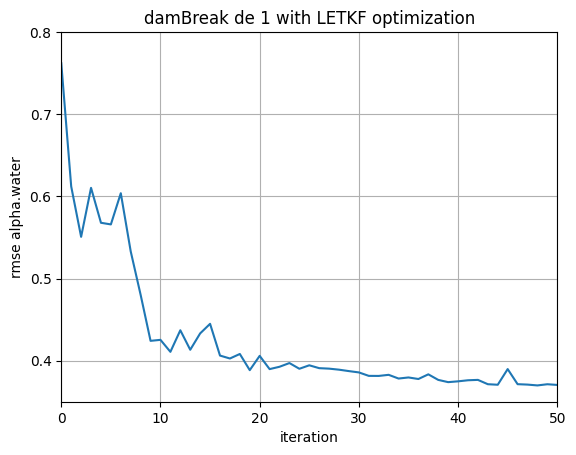

In [18]:
import matplotlib.pyplot as plt 
rmses = np.loadtxt("./ensim1/member/logs/rmse.txt")

plt.plot(rmses)
plt.grid(True)
plt.ylabel("rmse alpha.water")
plt.xlabel("iteration")
plt.xlim((0,50))
plt.ylim((0.35,0.8))
plt.title("damBreak de 1 with LETKF optimization")
plt.savefig("./ensim1/rmse.png")
plt.savefig("./ensim1/rmse.svg")

In [29]:
ensim.shutdown_ray()

In [22]:
ensim.letkf_update()

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(ensim.y0- ensim.xf[:,-50:].mean(axis=0)))))


(pid=203433)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

0.4252204786504662


In [27]:
ensim.letkf_update()

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(ensim.y0- ensim.xf[:,-50:].mean(axis=0)))))


(pid=204379)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

0.3361718370730322


In [29]:

ensim.xa[:,obs_cells].mean(axis=0)

array([0.        , 0.        , 0.        , 0.16707379, 0.23206047,
       0.        , 0.        , 0.        , 0.04116507, 0.22924742,
       0.80286058, 0.61897858, 0.33681699, 0.63541729, 0.99869948,
       1.        , 1.        , 1.        , 0.97612033, 0.98904975,
       0.8407334 , 1.00535363, 0.78365646, 1.        , 1.        ,
       0.86620722, 1.        , 1.        , 0.55790745, 0.97769141,
       0.88480037, 0.98495428, 0.91719447, 1.        , 0.90891519,
       0.80799352, 0.95719327, 0.        , 0.24689648, 0.24311403,
       0.46347879, 0.63059655, 0.49133201, 0.33423423, 0.23289322,
       0.        , 0.        , 0.        , 0.        , 0.08587819])

In [67]:

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(y0- ensim.xf[:,-50:].mean(axis=0)))))
ensim.letkf_update()

print(ensim.xa[:,obs_cells][:,23:27].mean(axis=0) )
ensim.xa[:,obs_cells].mean(axis=0) > 0.5

0.47113455804363336


(pid=196880)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

[0.79416195 0.84179221 0.42356902 0.09836496]


array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False])

In [68]:
ensim.shutdown_ray()

In [39]:
ensim.xa[:,obs_cells].mean(axis=0) > 0.5

array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])

0.848528137423857

In [29]:
np.square(y0-ensim.xa.mean(axis=0)[-50])

array([2.79747196e-05, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 2.79747196e-05])

array([False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False])

In [54]:
fromXset = {"alpha.water":(slice(0,n_cells),"0",["alpha.water"],None),
            "alpha_wall":(slice(n_cells, dim_x),"0.45",["alpha.water"],obs_cells)}

In [19]:
fromXset = {"alpha.water":(slice(0,n_cells),"0",["alpha.water"],None),
            "alpha_wall":(slice(n_cells, dim_x),"0.45",["alpha.water"],obs_cells)}

def func_get_xfi(case, fromXset):
    xf = esarray(np.empty(dim_x))
    for key in fromXset:
        xslice = fromXset[key][0]
        time_name = fromXset[key][1]
        x_name = fromXset[key][2]
        cells = fromXset[key][3]
        xf[xslice] = case.getValues(time_name, x_name, cells)
    return xf

ensim.func_get_xfi = func_get_xfi
xfn = ensim.get_xf(ensim.cases, fromXset)
sd = {k: v[0] for k,v in fromXset.items()}
xf = esarray(xfn.T,state_dict=sd)


In [17]:
ensim.func_get_xfi = func_get_xfi
xfn = ensim.get_xf(ensim.cases, fromXset)
sd = {k: v[0] for k,v in fromXset.items()}
xf = esarray(xfn.T,state_dict=sd)

In [18]:
xf.get_st_value("alpha.water").shape

(20, 2268)

In [6]:
fromXset = {"alpha.water":("0.45","alpha.water",None),
            "alpha_wall":("0.45","alpha.water",obs_cells)}

<function dict.keys>

In [54]:
ensim.x_names = ["alpha.water"]
ensim.n_x_scaler=1


In [19]:
#ensim.xf=aaa
#cp -r member/case/0.org member/case/0
#member/case/0/alpha.water  ← ensim.xf
#ensim.forcast()
#ensim.xf[:,-500:] =get wall values form 0.45/alpha.water


In [4]:
from foamdapy.foamer import OFCase
orgcase = OFCase("./ensim1/damBreak.org")
xf0 = orgcase.getValues("0",["alpha.water"])

cent = orgcase.getValues("0",["Cx"])
right_wall_index = np.where(cent == cent.max())[0]
xf1 = orgcase.getValues("0.45", ["alpha.water"],right_wall_index)

In [37]:
xf1

array([3.05857e-08, 7.12736e-08, 8.55904e-07, 8.82821e-06, 6.12643e-05,
       3.15497e-04, 1.27076e-03, 4.16149e-03, 1.11767e-02, 3.93311e-02,
       4.84632e-01, 8.21182e-01, 8.73722e-01, 9.15934e-01, 9.39197e-01,
       9.39197e-01, 9.39197e-01, 9.04085e-01, 8.84089e-01, 7.43213e-01,
       7.41936e-01, 7.42119e-01, 8.07415e-01, 8.79520e-01, 8.71844e-01,
       3.87061e-01, 6.89088e-02, 6.64392e-02, 6.62257e-02, 6.62133e-02,
       6.62147e-02, 9.33018e-02, 2.79253e-01, 2.78850e-01, 2.77716e-01,
       2.77142e-01, 2.76247e-01, 2.73630e-01, 2.70896e-01, 2.67770e-01,
       2.66089e-01, 2.59374e-01, 2.39460e-01, 2.35279e-01, 2.32942e-01,
       1.93779e-01, 7.48833e-02, 9.84003e-02, 1.15263e-01, 8.34962e-02])

In [3]:
from PyFoam.RunDictionary.ParsedParameterFile import ParsedParameterFile


In [4]:
al = ParsedParameterFile("./ensim1/damBreak.org/0.45/alpha.water")

In [15]:
al.content["boundaryField"]

{'leftWall': {'type': 'zeroGradient'},
 'rightWall': {'type': 'zeroGradient'},
 'lowerWall': {'type': 'zeroGradient'},
 'atmosphere': {'type': 'inletOutlet',
  'inletValue': 'uniform 0',
  'value': 'nonuniform List<scalar> 46
  (
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0.00558338
    0
    0
    6.78416e-05
    6.78416e-05
    0.0834962
  )
  '},
 'defaultFaces': {'type': 'empty'}}